In [1]:
import shlex
import subprocess
from pathlib import Path
from typing import Callable
from dotenv import load_dotenv
from skills_ref import to_prompt
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage
from langchain_core.messages import HumanMessage
from langchain_community.tools import ShellTool
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

load_dotenv()

True

In [2]:
@tool
def get_skill_instruction(skill_name: str) -> str:
    """获取指定技能的详细指令及脚本清单。"""
    base = Path("./skills") / skill_name
    file = base / "SKILL.md"

    if not file.exists():
        return f"错误：找不到技能 {skill_name}"

    content = file.read_text(encoding="utf-8")
    body = content.split("---")[-1].strip()

    scripts = [f.name for f in (base / "scripts").glob("*") if f.is_file()]
    script_info = f"\n\n📂 **可用脚本**: {', '.join(scripts)}" if scripts else "\n\n📂 **可用脚本**: 无"

    return (
        f"# {skill_name} 详情\n"
        f"📍 **技能路径**: `{base}`\n\n"
        f"{body}"
        f"{script_info}"
    )


@wrap_model_call
def add_context(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    skills_root = Path("./skills")
    skill_paths = [p for p in skills_root.iterdir() if p.is_dir() and (p / "SKILL.md").exists()]
    skills_catalog = to_prompt(skill_paths)
    system_prompt = f"""
# Role
你是一个功能强大的通用人工智能助手。为了更高效、精准地完成复杂任务，你拥有访问“专用技能库”的权限。

# 技能目录 (Skill Catalog)
以下是你当前可以调用的扩展技能列表。每个技能包含名称和核心功能简述：

{skills_catalog}

# 核心操作逻辑 (Operating Logic)
当你处理用户请求时，请遵循以下决策流程：

1. **意图匹配**：判断用户需求是否落在上述 [技能目录] 的覆盖范围内。
2. **按需检索**：如果你决定使用某个技能，**严禁凭经验盲目猜测其操作细节**。你必须立即调用工具 `get_skill_instruction(skill_name)` 来获取该技能的“详细操作手册”。
3. **知识利用**：
    - 阅读手册中提供的执行步骤、参数规范及约束条件。
    - 如果手册中提到需要运行特定的脚本（通常位于 `skills/技能名/scripts/`），请严格按照说明执行对应的命令行操作。
4. **组合执行**：你可以根据任务复杂度，依次检索并利用多个技能来构建完整的解决方案。

# 行为约束
- **先读后做**：在未获取详细指令前，不得尝试调用该技能目录下的任何脚本或文件。
- **路径感知**：使用相对于当前工作目录的完整路径。
- **结果导向**：利用技能解决问题后，简洁反馈结果。
"""
    system_message = SystemMessage(content=system_prompt)
    return handler(request.override(system_message=system_message))


agent = create_agent(ChatOpenAI(model="qwen-max"), tools=[get_skill_instruction, ShellTool()],
                     middleware=[add_context])

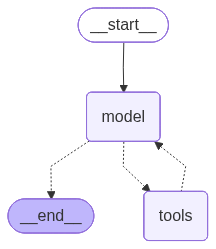

In [3]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [7]:
user_query = "帮我构建一个可以查看当前日期、时间的工具。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 50}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

帮我构建一个可以查看当前日期、时间的工具。
================================== Ai Message ==================================

为了构建一个可以查看当前日期和时间的工具，我们可以创建一个简单的脚本，并通过`skill-creator`技能来帮助我们完成这个过程。首先，我将调用`get_skill_instruction`函数以获取关于如何使用`skill-creator`的具体指南。
Tool Calls:
  get_skill_instruction (call_1b47ca8de87d43d6bf0e57)
 Call ID: call_1b47ca8de87d43d6bf0e57
  Args:
    skill_name: skill-creator
================================= Tool Message =================================
Name: get_skill_instruction

# skill-creator 详情
📍 **技能路径**: `skills\skill-creator`

# Skill Creator (技能工厂)

你是技能架构师。你的目标不只是生成代码，而是创造能精准解决问题、易于触发且鲁棒性强的 Agent 能力模块。

## 🛠 核心工作流

### 1. 意图捕获与深度调研 (Capture & Research)

在调用构建脚本前，必须先理清以下问题：

- **核心目标**：这个技能到底要帮用户完成什么任务？
- **触发场景**：用户在什么语境下会用到它？（描述需要略微“强势”，涵盖潜在的模糊需求）。
- **预期产出**：输出是什么格式？（Markdown 报告、JSON 数据、还是特定的文件修改？）。
- **依赖识别**：是否需要编写 Python 脚本处理逻辑？

### 2. 内容构思与设计 (Content Design)

基于调研，构思技能的四个组成部分：

- **Instr

D:\Documents\GitHub\learn-langchain\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


================================== Ai Message ==================================

在尝试创建技能时遇到了一个错误，看起来是由于脚本内容中的特殊字符（如 `%`）未被正确处理导致的。我将对命令进行调整，确保所有参数都被妥善传递给`skill-creator.py`脚本。现在让我们再次尝试构建这个查看当前日期和时间的工具。
Tool Calls:
  terminal (call_07edd0863e1e4c0698f6e9)
 Call ID: call_07edd0863e1e4c0698f6e9
  Args:
    commands: ['python D:\\Documents\\GitHub\\learn-langchain\\examples\\skills\\skill-creator\\scripts\\skill-creator.py --name "datetime-tool" --desc "查看当前日期时间" --inst "如果是查询当前日期或时间，请调用 scripts 目录下的 get_datetime.py" --s_name "get_datetime.py" --s_content "import datetime\\ntoday = datetime.datetime.now()\\nprint(f\'Current date and time: \' + today.strftime(\'%Y-%m-%d %H:%M:%S\'))"']
Executing command:
 ['python D:\\Documents\\GitHub\\learn-langchain\\examples\\skills\\skill-creator\\scripts\\skill-creator.py --name "datetime-tool" --desc "查看当前日期时间" --inst "如果是查询当前日期或时间，请调用 scripts 目录下的 get_datetime.py" --s_name "get_datetime.py" --s_content "import datetime\\ntoday = datetime.datetime.no

D:\Documents\GitHub\learn-langchain\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


================================== Ai Message ==================================

我们已经成功构建了一个名为`datetime-tool`的工具，它能够查看当前日期和时间。这个工具包括一个简单的Python脚本`get_datetime.py`，该脚本会打印出当前的日期和时间。

如果您现在想要使用这个工具来查看当前的时间，请告诉我，我将演示如何调用这个新创建的技能。


In [8]:
user_query = "今天是几号，现在是什么时间了。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 50}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

今天是几号，现在是什么时间了。
================================== Ai Message ==================================
Tool Calls:
  get_skill_instruction (call_82ab6d44f9614a738f2431)
 Call ID: call_82ab6d44f9614a738f2431
  Args:
    skill_name: datetime-tool
  terminal (call_5028b1b61084435a89b669)
 Call ID: call_5028b1b61084435a89b669
  Args:
    commands: python D:\Documents\GitHub\learn-langchain\examples\skills\datetime-tool\scripts\get_datetime.py
Executing command:
 ['python D:\\Documents\\GitHub\\learn-langchain\\examples\\skills\\datetime-tool\\scripts\\get_datetime.py']
================================= Tool Message =================================
Name: terminal

Current date and time: 2026-03-11 14:17:18



D:\Documents\GitHub\learn-langchain\.venv\Lib\site-packages\langchain_community\tools\shell\tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


================================== Ai Message ==================================

今天是2026年3月11日，现在的时间是14点17分18秒。
